In [214]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

In [215]:
from PyQt6.QtWidgets import QApplication, QFileDialog

def select_folder_pyqt6():
    # Create application
    app = QApplication(sys.argv)

    # Open folder dialog
    folder_path = QFileDialog.getExistingDirectory(
        None,
        "Select a folder",
        ""
    )

    # Close QApplication
    app.exit()

    return folder_path

path = select_folder_pyqt6()
print(f"path: {path}")

path: X:/Anlagen/_lab31316-nlo/Inbox/experiment/202511_NLO_measurement_results/20260209_1221_BMF36-B0_d24_rotation


### Select fitting strategy

In [216]:
from shg_analysis import SHGDataAnalysis
from crystaldatabase import CRYSTALS
from crystaldatabase import *

analysis = SHGDataAnalysis(path)
meta = analysis.meta
data = analysis.data

crystal = CRYSTALS[meta["material"]]()

if crystal.axiality == "uniaxial":
    from fitting_strategies.jerphagnon1970 import Jerphagnon1970Strategy
    strategy = Jerphagnon1970Strategy(analysis)

elif crystal.axiality == "biaxial":
    # from fitting_strategies.ishidate1974 import Ishidate1974Strategy
    # strategy = Ishidate1974Strategy(analysis)
    from fitting_strategies.bechthold1977 import Bechthold1977Strategy
    strategy = Bechthold1977Strategy(analysis)
    # from fitting_strategies.shoji1997 import Shoji1997RotationStrategy
    # strategy = Shoji1997RotationStrategy(analysis)

In [217]:
fringe = strategy._maker_fringes(override={"theta_deg":data["position"]})
envelope = strategy._maker_fringes(override={"theta_deg":data["position"]}, envelope=True)

x = analysis.data["position"]
BBO_ref = analysis.data["ch1"]
raw_intensity = analysis.data["ch2"]
intensity_corrected = analysis.data["intensity_corrected"]

### theoretical fringe before fitting

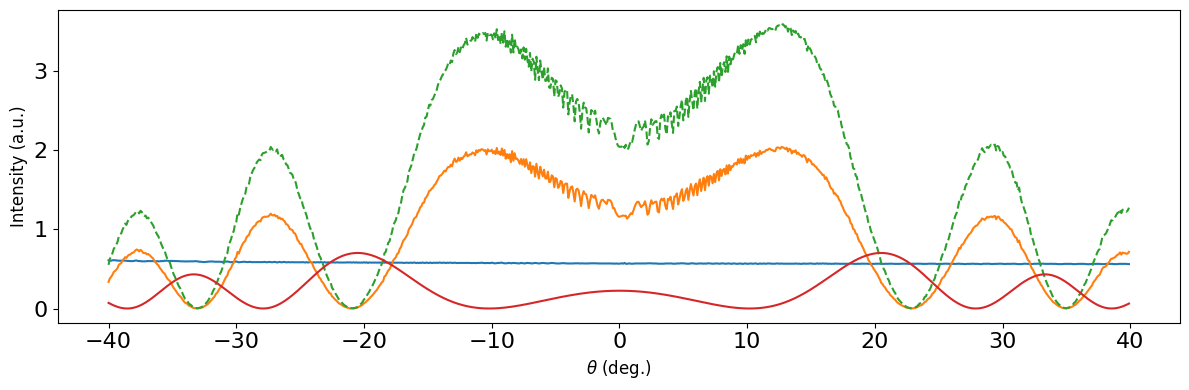

In [218]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, BBO_ref, label='BBO')
ax.plot(x, raw_intensity, label='raw')
ax.plot(x, intensity_corrected, label='intensity_corrected', linestyle='--')
ax.plot(x, fringe, label='theoretical curve')
# ax.plot(x, envelope, label='envelope')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
if np.max(envelope) > 10.0:
      ax.set_ylim(0, 10)

fig.tight_layout()
# ax.legend(loc='upper left')
plt.show()

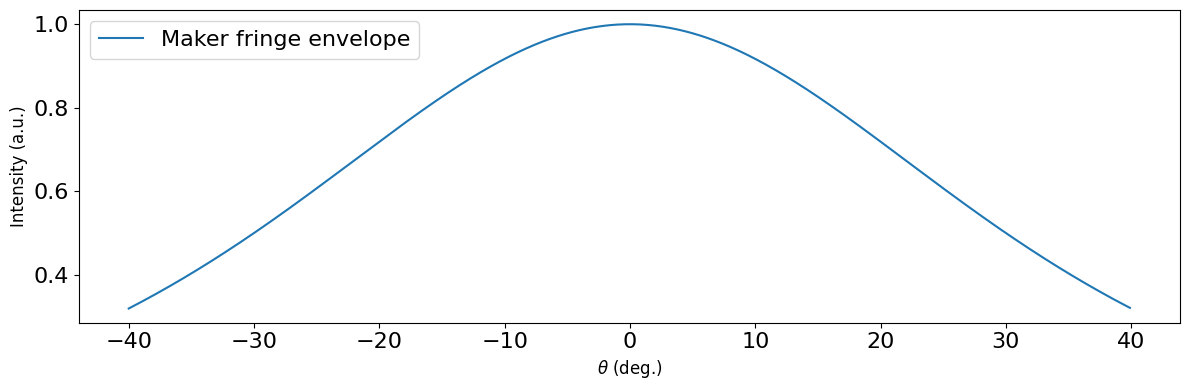

In [219]:
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, envelope, label='Maker fringe envelope')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)
# ax.set_yscale("log")

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

In [220]:
try:
    results = strategy.fit_all()
except Exception as e:
    print(f"Error:{e}")
# results = strategy.fit_all()

Error: No valid adjacent-minima pairs to compute Lc.


### Offset subtraction

offset:  0.0033500837520938024


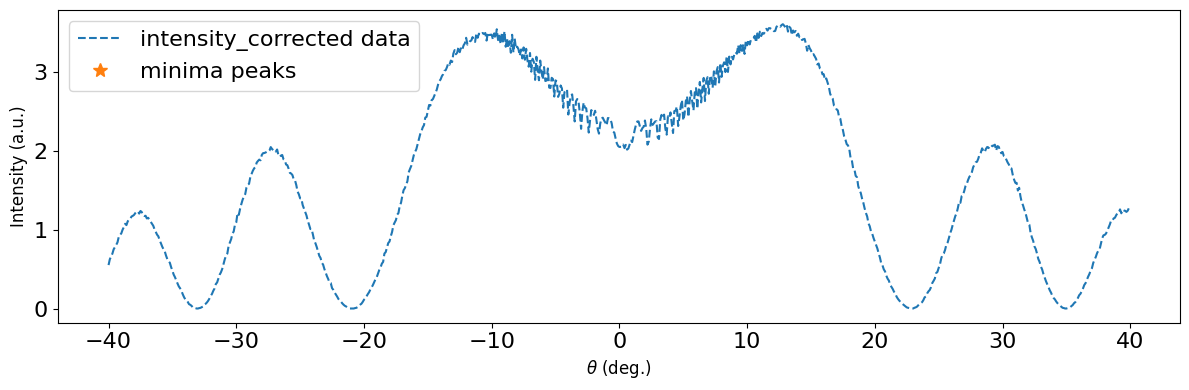

In [221]:
_, fit_offset = strategy._subtract_offset(analysis.data)
minima_x = x[fit_offset["minima_idx"]]
minima_y = intensity_corrected[fit_offset["minima_idx"]]
offset = fit_offset["offset"]
print("offset: ",offset)


plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(minima_x, minima_y, "*", ms=10, label='minima peaks')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(-0.1, 3.2)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()


In [222]:
print(minima_x)

Series([], Name: position, dtype: float64)


### Position centering fit

center position:  0.96804


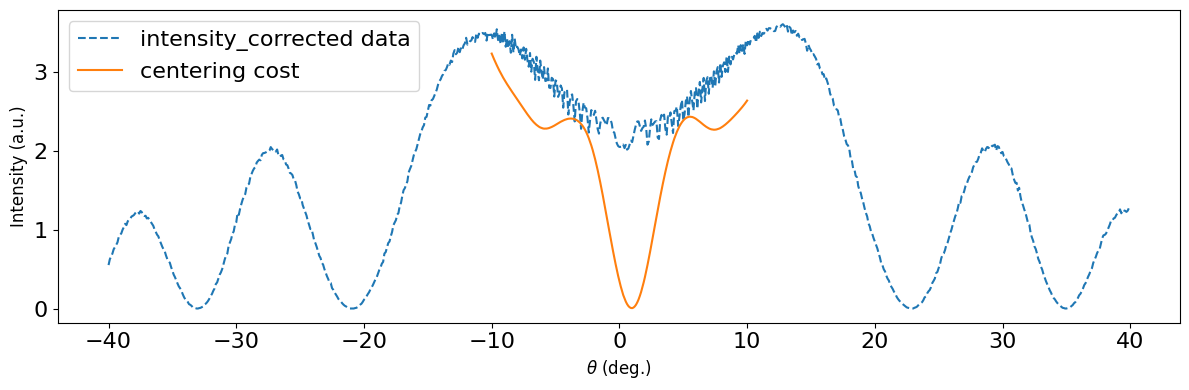

In [223]:
_, fit_centering = strategy._position_centering(analysis.data)
center_x = fit_centering["c_candidates"]
center_cost = fit_centering["costs"]
center = fit_centering["c_best"]
print("center position: ",center)


plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(center_x, center_cost, label='centering cost')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 3.2)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()


### sample thickness fitting

In [224]:
L_fit = strategy._fit_L_small_angle(meta, analysis.data)
print(f"measured thickness:{analysis.meta["thickness_info"]["t_center_mm"]}")
print(L_fit)

L_override = L_fit["L_mm"]

measured thickness:1.389
{'L_mm': 1.379000000000019, 'L_mm_std': 0.008546656443891333, 'k_scale': 8.725309122904703, 'k_scale_std': 2.1349873001127686}


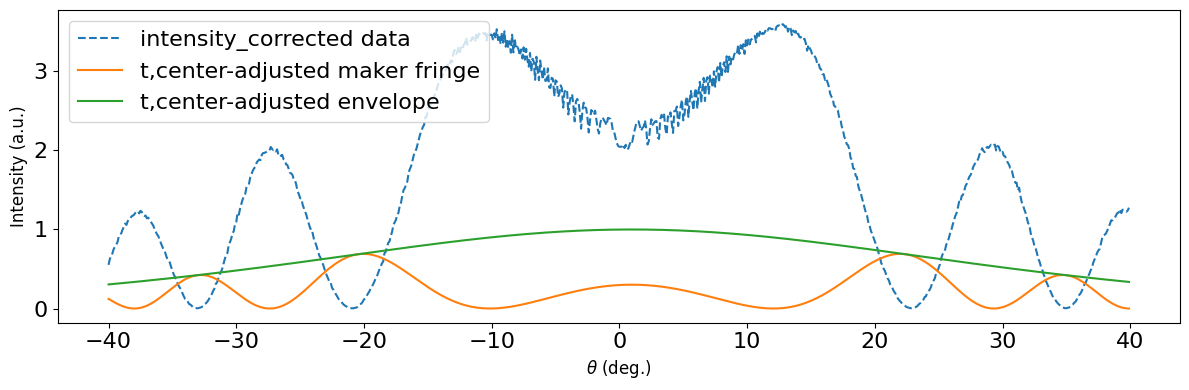

In [225]:
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

L_fitted_fringe = strategy._maker_fringes(override={"L":L_override})
L_fitted_envelope = strategy._maker_fringes(envelope=True, override={"L":L_override})

ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(x, L_fitted_fringe, label='t,center-adjusted maker fringe')
ax.plot(x, L_fitted_envelope, label='t,center-adjusted envelope')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
if np.max(L_fitted_envelope) > 15.0:
      ax.set_ylim(0, 12)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Calculate Lc

In [226]:
try:
    lc_results, fit_Lc = strategy._calc_Lc_large_angle(analysis.meta, analysis.data, [0,180], L_fit["L_mm"], minima_threshold=0.05)

    position_centered = strategy.analysis.data["position_centered"] 
    minima_x = position_centered[fit_Lc["minima_idx"]]
    minima_y = intensity_corrected[fit_Lc["minima_idx"]]

    theta_in_range = x[fit_Lc["x_in_range"]]
    y = [1 for i in theta_in_range]


    plt.rcParams['font.size'] = 10
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(position_centered, intensity_corrected, label='intensity_corrected data', linestyle='--')
    ax.plot(minima_x, minima_y, "*", ms=10, label='minima peaks')
    # ax.plot(theta_in_range, y, "*")

    ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
    ax.set_ylabel('Intensity (V)', fontsize=12)

    # ax.set_xlim(-20, 20)
    # ax.set_ylim(-0.1, 3.2)

    fig.tight_layout()
    ax.legend(loc='upper left')
    plt.show()
    Lc_calc = True

    print(f"minima:{minima_x}")

    print(f"pos side:{fit_Lc["dL_pos"]}\n")
    print(f"neg side:{fit_Lc["dL_neg"]}\n")
    print(f"Lc: {lc_results["Lc_mean_mm"]*1000} ± {lc_results["Lc_std_mm"]*1000} um")

except Exception as e:
    print(f"Error during '_calc_Lc_large_angle':{e}")
    Lc_calc = False


Error during '_calc_Lc_large_angle':No valid adjacent-minima pairs to compute Lc.


In [227]:
if Lc_calc is False:
    pass
else:
    # ---- Ensure numpy array ----
    minima_x = np.asarray(minima_x)

    # ---- Split minima ----
    minima_pos = minima_x[minima_x > 0]
    minima_neg = minima_x[minima_x < 0]

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(12, 4))

    # Positive side
    for i, Lc in enumerate(fit_Lc["dL_pos"]):
        ax.plot(
            [minima_pos[i], minima_pos[i + 1]],
            [1000.0 * Lc, 1000.0 * Lc],
            color="C0"
        )

    # Negative side
    for i, Lc in enumerate(fit_Lc["dL_neg"]):
        ax.plot(
            [minima_neg[i], minima_neg[i + 1]],
            [1000.0 * Lc, 1000.0 * Lc],
            color="C0"
        )

    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Coherence length Lc (µm)")
    # ax.set_ylim(7.5, 11.5)
    ax.set_title("Lc from adjacent minima pairs")

    ax.grid(True)
    plt.tight_layout()
    plt.show()

### Calculate Lc manually

In [228]:
wl1_nm = meta["wavelength_nm"]
wl1_mm = wl1_nm * 1e-6
pol_in = meta["input_polarization"] # 0-90 deg
pol_out = meta["detected_polarization"] # 0-90 deg

fitted_L_mm = L_fit["L_mm"]

def differential_L(th_list):
    if th_list.size < 2:
        return np.array([], dtype=float)
    
    th_rad = np.radians(th_list)
    lc_list = []
    for i in range(th_rad.size - 1):
        # Use midpoint refractive indices between adjacent angles
        n_w = strategy.n_eff(pol_in, wl1_nm, th_list[i])
        n_2w = strategy.n_eff(pol_out, wl1_nm / 2.0, th_list[i])

        lc = fitted_L_mm * (np.sin(th_rad[i + 1])**2 - np.sin(th_rad[i])**2) / (4.0 * n_2w * n_w)
        lc_list.append(abs(lc))

    return np.asarray(lc_list, dtype=float)

In [229]:
theta_list_lc = np.array([7, 14.4])
lc = differential_L(theta_list_lc)

print(f"Lc: {lc}")

FittingConfigurationError: Unexpected polarization degree: 45.0. Supported values are 0 or 90 degree.

### Intensity fit

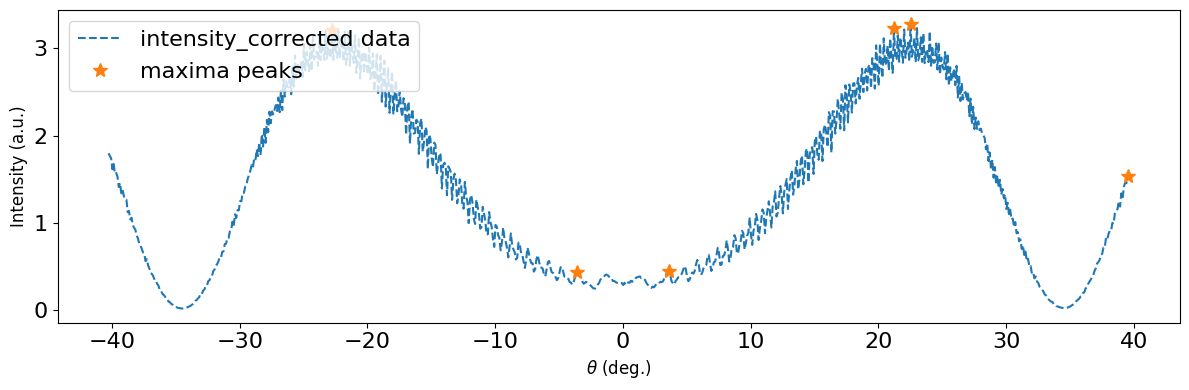

In [ ]:
fit_results, fit_Pm0 = strategy._fit_Pm0(analysis.data)
position_centered = strategy.analysis.data["position_centered"]
maxima_x = position_centered[fit_Pm0["maxima_idx"]]
maxima_y = intensity_corrected[fit_Pm0["maxima_idx"]]


plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(position_centered, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(maxima_x, maxima_y, "*", ms=10, label='maxima peaks')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(0.0, 4)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()


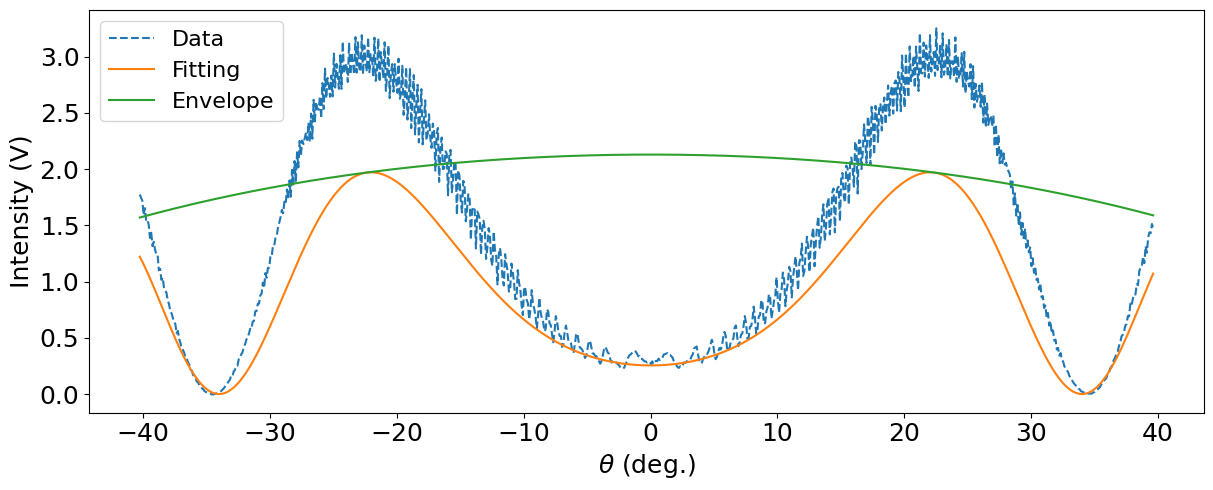

In [ ]:
k = fit_results["Pm0"]
L = L_fit["L_mm"]
position_centered = strategy.analysis.data["position_centered"]

fitted_fringe = k * strategy._maker_fringes(override={"L":L, "theta_deg": position_centered})
fitted_envelope = k * strategy._maker_fringes(envelope=True, override={"L":L, "theta_deg": position_centered})

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(position_centered, intensity_corrected - offset, label='Data', linestyle='--')
ax.plot(position_centered, fitted_fringe, label='Fitting')
ax.plot(position_centered, fitted_envelope, label='Envelope')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=18)
ax.set_ylabel('Intensity (V)', fontsize=18)

ax.tick_params(axis="both", labelsize=18)

# ax.set_xlim(-20, 20)
if np.max(fitted_envelope) > 10.0:
      ax.set_ylim(0, np.max(intensity_corrected)*1.1)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

In [ ]:
print(f"k: {k}")

k: 2.1300182545637893


### Calculate Lc from theoretical fringe

In [ ]:
# checking how Lc is sorted

th_pos = np.sort(position_centered[position_centered > 0.0])
th_neg = np.sort(position_centered[position_centered < 0.0])
print(f"pos:{th_pos[:5]}")
print(f"neg:{th_neg[:5]}")

pos:[0.03196 0.13196 0.23196 0.33196 0.43196]
neg:[-40.26804 -40.16804 -40.06804 -39.96804 -39.86804]


In [ ]:
import pandas as pd    
theoretical_data = pd.DataFrame()
# theoretical_data["position_centered"] = position_centered
# theoretical_data["intensity_corrected"] = fitted_fringe
# theoretical_data["position"] = np.linspace(-40, 40, 800)

data_points = 4000 + 1

theoretical_data["position_centered"] = np.linspace(-40, 40, data_points)
theoretical_data["intensity_corrected"] = \
    k * strategy._maker_fringes(override={"L":L, "theta_deg": theoretical_data["position_centered"]})
theoretical_data["position"] = np.linspace(-40, 40, data_points)

# print(np.size(theoretical_data["intensity_corrected"]))
# test_pos = theoretical_data.get("position_centered", theoretical_data["position"])
# print(test_pos[:5])
# lc_th_results, fit_th_Lc = strategy._calc_Lc_large_angle(meta, theoretical_data, [0,180], L_fit["L_mm"])


In [ ]:
try:   
    lc_th_results, fit_th_Lc = strategy._calc_Lc_large_angle(meta, theoretical_data, [0,180], L_fit["L_mm"])

    position = np.asarray(theoretical_data["position_centered"])
    fitted_fringe = np.asarray(theoretical_data["intensity_corrected"])
    minima_x = position[fit_th_Lc["minima_idx"]]
    minima_y = fitted_fringe[fit_th_Lc["minima_idx"]]

    plt.rcParams['font.size'] = 10
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(position, fitted_fringe, label='Fit', linestyle='--')
    ax.plot(minima_x, minima_y, "*", ms=10, label='minima peaks')

    ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
    ax.set_ylabel('Intensity (V)', fontsize=12)
    # ax.set_xlim(-20, 20)
    # ax.set_ylim(-0.1, 3.2)

    fig.tight_layout()
    ax.legend(loc='upper left')
    plt.show()
    Lc_th_calc = True

    print(f"minima:{minima_x}")

    print(f"pos side:{fit_th_Lc["dL_pos"]}\n")
    print(f"neg side:{fit_th_Lc["dL_neg"]}\n")
    print(f"Lc: {lc_th_results["Lc_mean_mm"]*1000} ± {lc_th_results["Lc_std_mm"]*1000} um")

except Exception as e:
    print(f"Error during '_calc_Lc_large_angle':{e}")
    Lc_th_calc = False

Error during '_calc_Lc_large_angle':No valid adjacent-minima pairs to compute Lc.


In [ ]:
if Lc_th_calc is False:
    pass
else:
    # ---- Ensure numpy array ----
    minima_x = np.asarray(minima_x)

    # ---- Split minima ----
    minima_pos = minima_x[minima_x > 0]
    minima_neg = minima_x[minima_x < 0]

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(12, 4))

    # Positive side
    for i, Lc in enumerate(fit_th_Lc["dL_pos"]):
        ax.plot(
            [minima_pos[i], minima_pos[i + 1]],
            [1000.0 * Lc, 1000.0 * Lc],
            color="C0"
        )

    # Negative side
    for i, Lc in enumerate(fit_th_Lc["dL_neg"]):
        ax.plot(
            [minima_neg[i], minima_neg[i + 1]],
            [1000.0 * Lc, 1000.0 * Lc],
            color="C0"
        )

    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Coherence length Lc (µm)")
    ax.set_title("Lc from adjacent minima pairs")

    ax.grid(True)
    plt.tight_layout()
    plt.show()

### Change L manually for better fitting

In [233]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- Plot style control (single variable) ----
ft = 16  # Change this to scale everything

plt.rcParams.update({
    "font.size": ft,
    "axes.titlesize": ft,
    "axes.labelsize": ft,
    "xtick.labelsize": ft,
    "ytick.labelsize": ft,
    "legend.fontsize": ft,
})

# ---- Angle axis ----
theta_deg = position_centered

# ---- L settings ----
L0_mm = analysis.meta["thickness_info"]["t_center_mm"]  # <-- set your nominal L here [mm]
L_fit_mm = L_fit["L_mm"]
dL_um = 150.0   # +/- range [um]
dL_mm = dL_um / 1000.0

# ---- Vertical scale settings ----
A0 = fit_results["Pm0"]          # Initial vertical scale
A_range = np.max(intensity_corrected) * 2.0


slider_dL = widgets.FloatSlider(
    value=0.0,
    min=-dL_um,
    max=+dL_um,
    step=dL_um / 300.0,
    description="ΔL (µm)",
    continuous_update=True,
    readout=True,
    readout_format=".1f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="520px"),
)

slider_A = widgets.FloatSlider(
    value=A0,
    min=0,
    max=A_range,
    step=A_range / 300.0,
    description="Scale A",
    continuous_update=True,
    readout=True,
    readout_format=".2f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="520px"),
)

btn_reset = widgets.Button(description="Reset", layout=widgets.Layout(width="120px"))

out = widgets.Output()

def redraw(dL_current_um: float, A: float):
    L_mm = L_fit_mm + dL_current_um / 1000.0
    delta_L = (L_mm - L0_mm) * 1000
    fringe_manual = A * strategy._maker_fringes(override={"L":L_mm, "theta_deg": position_centered}) \
      + offset
    envelope_manual = A * strategy._maker_fringes(override={"L":L_mm, "theta_deg": position_centered}, envelope=True) \
      + offset

    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 4))
        # ax.plot(theta_deg, intensity_corrected, "*", color="green", label='Data')
        # ax.plot(theta_deg, fringe_manual, lw=2, linestyle="-", color="orange", label="Fitting")
        # ax.plot(theta_deg, envelope_manual, lw=2, linestyle="-", color="blue", label="Envelope")
        ax.plot(theta_deg, intensity_corrected, "*", label='Data')
        ax.plot(theta_deg, fringe_manual, lw=2, linestyle="-", label="Fitting")
        ax.plot(theta_deg, envelope_manual, lw=2, linestyle="-", label="Envelope")
        ax.set_title("Maker fringe vs incidence angle")
        ax.set_xlabel("Incidence angle (deg)")
        ax.set_ylabel("Intensity (V)")
        # ax.set_xlim(theta_min, theta_max)
        # ax.set_ylim(-0.05, 1.05)
        # ax.set_ylim(0, np.max(intensity_corrected) * 1.2)
        ax.grid(True)
        ax.text(
            0.02, 0.95,
            f"L = {L_mm:.4f} mm  (ΔL = {delta_L:+.1f} µm)\nPeak ={A:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=ft
        )
        # ax.legend(loc="upper right")
        ax.legend(fontsize=ft)
        plt.show()

def _on_slider_change(_=None):
    redraw(slider_dL.value, slider_A.value)


def _on_reset(_):
    slider_dL.value = 0.0
    slider_A.value = A0

slider_dL.observe(lambda ch: _on_slider_change(), names="value")
slider_A.observe(lambda ch: _on_slider_change(), names="value")
btn_reset.on_click(_on_reset)

display(widgets.VBox([
    widgets.HBox([slider_dL, btn_reset]),
    slider_A,
    out
]))

# Initial draw
redraw(slider_dL.value, slider_A.value)

#### Note
20251227 quartz-1 d11
L =0.5033 (-7.7 um)
A = 2.60

20251227 KDP-1 d36
L=0.2438
A = 1.82

### Comparison with reference

In [ ]:
# KDP vs quartz

# fit, aux = strategy._maker_fringes(override={"L":L, "theta_deg": position_centered}, return_aux=True)
# quartz d11 sensitivity=1/0.1V  OD=1+2
# OD1.0 (#1) transmission was 11.757399%
d_factor_quartzd11 = 366.5492256764717
peak_quartz = 2.60
d_propto_quartz = np.sqrt(0.1 * (1/0.1176) *peak_quartz / d_factor_quartzd11)

peak_quartz_0 = 3.45
d_propto_quartz_0 = np.sqrt(0.1 * (1/0.1176) *peak_quartz_0 / d_factor_quartzd11)

# quartz d11 sensitivity=1/0.2V  OD=1+2
peak_quartz_wedge = 1.29
d_propto_quartz_wedge = np.sqrt(0.2 * (1/0.1176) *peak_quartz_wedge / d_factor_quartzd11)

# KDP d36 sensitivity=1/0.1V  OD=1+2
# peak_KDP = 1.82
peak_KDP = 2.54
d_factor_KDP = 118.48921149685113
d_propto_KDP = np.sqrt(0.1 * (1/0.1176) * peak_KDP / d_factor_KDP)

quartz_KDP = d_propto_quartz_0 / d_propto_KDP 

d_abs_KDP = 0.39
d_abs_quartz = 0.30 # d11 from shoji, et.al.
d_rel_quartz = d_abs_KDP * quartz_KDP

print(f"KDP_vs_quartz: 1:{quartz_KDP}")
print(f"d_11_quartz{d_rel_quartz}")

KDP_vs_quartz: 1:0.6626221369252537
d_11_quartz0.258422633400849


In [ ]:
# path = select_folder_pyqt6()
# print(f"path: {path}")


# analysis_ref = SHGDataAnalysis(path)
# meta_ref = analysis_ref.meta
# data_ref = analysis_ref.data

# crystal_ref = CRYSTALS[meta_ref["material"]]()

# if crystal_ref.axiality == "uniaxial":
#     from fitting_strategies.jerphagnon1970 import Jerphagnon1970Strategy
#     strategy_ref = Jerphagnon1970Strategy(analysis_ref)

# elif crystal_ref.axiality == "biaxial":
#     from fitting_strategies.ishidate1974 import Ishidate1974Strategy
#     strategy_ref = Ishidate1974Strategy(analysis_ref)

In [ ]:
fit, aux = strategy._maker_fringes(override={"L":L, "theta_deg": position_centered}, return_aux=True)
d_factor = aux["d_factor"]

    # # ref
    # peak_ref = 1.286
    # _, aux_ref = strategy_ref._maker_fringes(return_aux=True)
    # d_factor_ref = aux_ref["d_factor"]
    # d_propto_ref = np.sqrt((1.0/0.11) * peak_ref / d_factor_ref)

    # ratio = d_propto/d_propto_ref 

    # d_ref_abs = 0.30 # d11 from shoji, et.al.
    # d_32_BMF = d_ref_abs * ratio

# BMF d32, d33 1 V/10 mV, OD2.0
d_propto = np.sqrt(0.01 * 1.0 * k / d_factor)



# BMFd31, 1/0.1 V, OD1+1+3.0
# d_propto = np.sqrt(0.1 * 1000 * 0.07 / d_factor)
ratio = d_propto/d_propto_quartz_wedge 

d_32_BMF = d_abs_quartz * ratio

print(aux["t"])
print(aux["T"])
print(f"ratio_to_quartz:{ratio}")
print(f"d_factor:{d_factor} ,d_32_BMF:{d_32_BMF}")

0.7892351739235474
1.4620915682391993
ratio_to_quartz:0.09853385416267457
d_factor:366.5492256764717 ,d_32_BMF:0.02956015624880237


### Graphs on demand

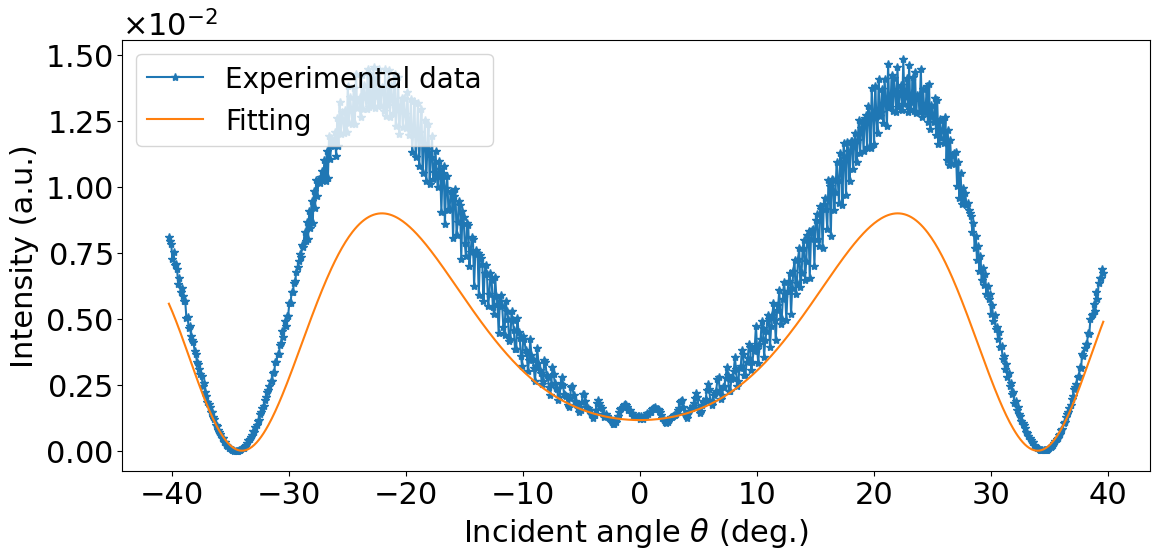

In [ ]:
from matplotlib.ticker import ScalarFormatter

plt.rcParams['font.size'] = 20
fig, ax = plt.subplots(figsize=(12, 6))

norm_to_quartz = peak_quartz_wedge * 20.0 * (1/0.1176)

ax.plot(position_centered, (intensity_corrected - offset)/norm_to_quartz ,'-*', label='Experimental data')
ax.plot(position_centered, fitted_fringe/norm_to_quartz, label='Fitting')
# ax.plot(position_centered, fitted_envelope, label='Envelope')

ax.set_xlabel(r'Incident angle $\theta$ (deg.)', fontsize=22)
ax.set_ylabel('Intensity (a.u.)', fontsize=22)

# Force scientific notation on y-axis
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
# Use math text (×10^{-3} instead of 1e−3)
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(22)

ax.tick_params(axis="both", labelsize=22)

# ax.set_xlim(-20, 20)
if np.max(fitted_envelope) > 10.0:
      ax.set_ylim(0, np.max(intensity_corrected)*1.1)

fig.tight_layout()
ax.legend(loc='upper left', fontsize=20)
plt.show()

### minima/maxima detection trial

In [ ]:
x = data["position_centered"]
y = data["offset_corrected"]

try:
    if x is None or y is None:
        raise RuntimeError("x/y is None.")

    period, idx, freq, fft = strategy.estimate_fringe_period(x, y)
    fft = np.abs(fft)

    print(f"estimated index: {idx} period :{period}")

    plt.figure()
    plt.plot(1/freq, fft, "-")
    plt.plot(1/freq[idx], fft[idx], "*", color="r")
    plt.xlabel("Period [deg]")
    plt.ylabel("FFT amplitude")
    plt.title("FFT of fringe data")
    # plt.xlim(0, 0.1)
    # plt.yscale("log")
    plt.grid(True)
    plt.show()

    # Also print an approximate window length suggestion, if period is valid
    if period is not None:
        dx = float(np.median(np.diff(x)))
        window = int((period / dx) / 3)
        if window < 5:
            window = 5
        if window % 2 == 0:
            window += 1
        print(f"dx ~ {dx:.6g} deg, suggested window length ~ {window} samples")

except Exception as e:
    print("estimate_fringe_period failed:", repr(e))

KeyError: 'position_centered'

### Theoretical fringe for different thickness

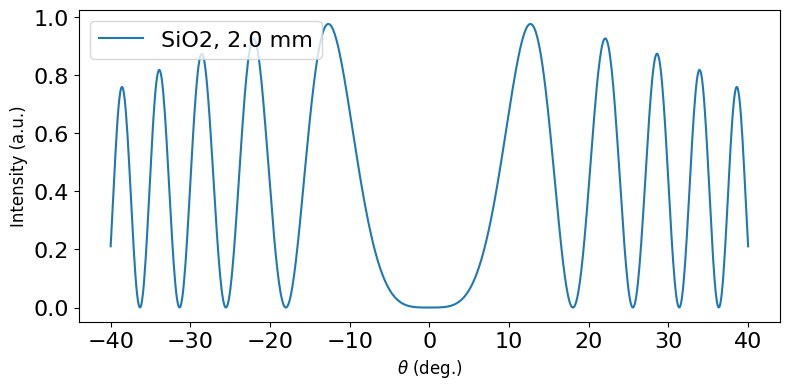

In [ ]:
meta = analysis.meta
data = analysis.data

import matplotlib.pyplot as plt
import numpy as np

mock_x = np.linspace(-40, 40, 800)

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(8, 4))

for i in [2.0]:
    fringe_on_L = strategy._maker_fringes(override={"L":i, "theta_deg":mock_x})
    # envelope = strategy._maker_fringes(override={"L":i}, envelope=True)
    ax.plot(mock_x, fringe_on_L, label=f'{meta["material"]}, {i} mm')
    # ax.plot(x, envelope, label=f'envelope at L={i}')

ax.set_xlabel(r'$\theta$ (deg.)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 3)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Calculate Lc from theoretical fringe

### Calculate signal dependent on L at theta=0

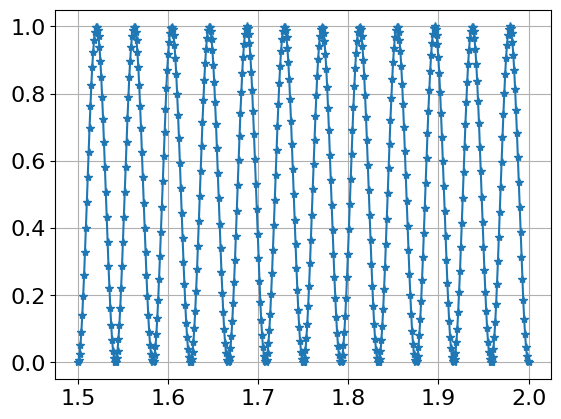

0.9999943763601469


In [ ]:
pos = np.linspace(1.5, 2.0, 500)
y = []
for i in pos:
    fringe = strategy._maker_fringes(override={"L":i, "theta_deg":0})
    y.append(fringe)

plt.plot(pos, y, "-*")
plt.grid(True)
plt.show()

print(np.max(y))